# Unit12 Example 04 | 烷化程序最大獲利

本 Notebook 以**烷化（Alkylation）程序最大獲利問題**為題，示範如何使用 `scipy.optimize.minimize(method='SLSQP')` 求解同時含有**等式限制**與**不等式限制**的複雜非線性規劃問題。

## 目標
- 識別並建立烷化程序中的線性等式、非線性等式、線性不等式與非線性不等式限制條件
- 正確將最大化問題轉換為最小化問題（目標函數取負號）
- 掌握 SLSQP 方法同時處理多類限制條件的完整工作流程
- 驗證最適化解之限制條件滿足度（等式殘差與不等式裕量核查）
- 探討不同起始猜測值對求解穩定性的影響
- 繪製最優操作條件視覺化圖表

**參考資料：** Edgar, T. F. and Himmelblau, D. M. (1989). *Optimization of Chemical Processes*. McGraw-Hill.

---
### 0. 環境設定

In [25]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit12_Example_04'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit12'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit12
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_04
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_04\figs


---
### 1. 載入套件

In [26]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import minimize, Bounds

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
    'figure.facecolor': 'white',
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")


✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題參數設定

#### 2.1 決策變數與目標函數參數

本問題含 **10 個決策變數**，目標為最大化每日獲利：

$$
f = c_1 x_4 x_7 - c_2 x_1 - c_3 x_2 - c_4 x_3 - c_5 x_5
$$

其中 $c_1 = 0.063$ ， $c_2 = 5.04$ ， $c_3 = 0.035$ ， $c_4 = 10.0$ ， $c_5 = 3.36$ 。

| 變數 | 物理意義 | 單位 | 下限 | 上限 |
|:---:|:---|:---:|---:|---:|
| $x_1$ | 烯烴進料量 | 桶/天 | 0 | 2000 |
| $x_2$ | 異丁烷回流量 | 桶/天 | 0 | 16000 |
| $x_3$ | 酸液添加率 | 千磅/天 | 0 | 120 |
| $x_4$ | 烷類產品產量 | 桶/天 | 0 | 5000 |
| $x_5$ | 異丁烷外加量 | 桶/天 | 0 | 2000 |
| $x_6$ | 酸液強度 | wt% | 85 | 93 |
| $x_7$ | 辛烷值 | — | 90 | 95 |
| $x_8$ | 外部 C4/C4= 比值 | — | 3 | 12 |
| $x_9$ | 酸稀釋因子 | — | 1.2 | 4 |
| $x_{10}$ | F-4 性能指數 | — | 145 | 162 |


In [ ]:
# =============================================
# 問題參數設定
# =============================================

# 目標函數成本參數
c1, c2, c3, c4, c5 = 0.063, 5.04, 0.035, 10.0, 3.36

# 變數上下限 (10 個決策變數)
x_lb = np.array([0,      0,     0,    0,    0,    85,  90,  3,   1.2, 145], dtype=float)
x_ub = np.array([2000, 16000, 120, 5000, 2000,   93,  95, 12,   4.0, 162], dtype=float)

# 起始猜測值（參考 Edgar & Himmelblau 推薦值）
x0 = np.array([1745, 12000, 110, 3048, 1974, 89.2, 92.8, 8.0, 3.6, 145], dtype=float)

# 變數名稱與物理意義
var_names   = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']
var_desc    = [
    '烯烴進料量 (BPSD)',
    '異丁烷回流量 (BPSD)',
    '酸液添加率 (klb/day)',
    '烷類產品產量 (BPSD)',
    '異丁烷外加量 (BPSD)',
    '酸液強度 (wt%)',
    '辛烷值',
    '外部 C4/C4= 比值',
    '酸稀釋因子',
    'F-4 性能指數',
]

# 顯示問題設定
print("=" * 55)
print("  烷化程序最大獲利 — 問題設定顯示")
print("=" * 55)
print(f"\n  {'變數':<6} {'物理意義':<22} {'下限':>7} {'上限':>8} {'起始值':>9}")
print("  " + "-" * 53)
for i, (vn, vd, lb, ub, x0v) in enumerate(zip(var_names, var_desc, x_lb, x_ub, x0)):
    print(f"  {vn:<6} {vd:<22} {lb:>7.1f} {ub:>8.1f} {x0v:>9.1f}")

print("\n  等式限制條件 (3 個):")
print("    (1) 線性:    1.22*x4 - x1 - x5 = 0")
print("    (2) 非線性:  x6*(x4*x9 + 1000*x3) - 98000*x3 = 0")
print("    (3) 非線性:  x8*x1 - x2 - x5 = 0")
print("\n  不等式限制條件 (8 個，含不確定性上下限):")
print("    (4)(5) 非線性: 產品產量迴歸關係 (d-=99/100, d+=100/99)")
print("    (6)(7) 非線性: 辛烷值迴歸關係  (d-=99/100, d+=100/99)")
print("    (8)(9) 線性:   酸稀釋因子與 F-4 性能指數關係")
print("    (10)(11) 線性: F-4 性能指數與辛烷值關係")
print("=" * 55)

  烷化程序最大獲利 — 問題設定顯示

  變數     物理意義                        下限       上限       起始值
  -----------------------------------------------------
  x1     烯烴進料量 (BPSD)               0.0   2000.0    1745.0
  x2     異丁烷回流量 (BPSD)              0.0  16000.0   12000.0
  x3     酸液添加率 (klb/day)            0.0    120.0     110.0
  x4     烷類產品產量 (BPSD)              0.0   5000.0    3048.0
  x5     異丁烷外加量 (BPSD)              0.0   2000.0    1974.0
  x6     酸液強度 (wt%)                85.0     93.0      89.2
  x7     辛烷值                       90.0     95.0      92.8
  x8     外部 C4/C4= 比值               3.0     12.0       8.0
  x9     酸稀釋因子                      1.2      4.0       3.6
  x10    F-4 性能指數                 145.0    162.0     145.0

  等式限制條件 (3 個):
    (1) 線性:    1.22*x4 - x1 - x5 = 0
    (2) 非線性:  x6*(x4*x9 + 1000*x3) - 98000*x3 = 0
    (3) 非線性:  x8*x1 - x2 - x5 = 0

  不等式限制條件 (8 個，含不確定性上下限):
    (4)(5) 非線性: 產品產量迴歸關係 (d-=99/100, d+=100/99)
    (6)(7) 非線性: 辛烷值迴歸關係  (d-=99/100, d+=100/99)
    (8)(9) 線性

---
### 3. 目標函數與限制條件定義

#### 3.1 SciPy SLSQP 限制條件格式說明

| 限制條件類型 | SciPy SLSQP 格式 |
|---|---|
| 等式：`f(x) = 0` | `{'type': 'eq', 'fun': f}` where `f(x) = 0` |
| 不等式：`f(x) ≥ 0` | `{'type': 'ineq', 'fun': f}` where `f(x) ≥ 0` |

> **注意：** SciPy 的不等式約定為 $c(\mathbf{x}) \geq 0$，建立限制函數時須將原不等式 $c(\mathbf{x}) \leq 0$ **取負號**轉換。

In [ ]:
# =====================================================================
# 目標函數
# =====================================================================
def objective(x):
    """目標函數：最大化每日獲利 → 最小化 -f
    f = c1*x4*x7 - c2*x1 - c3*x2 - c4*x3 - c5*x5
    變數索引 (0-based): x1=x[0], x2=x[1], ..., x10=x[9]
    """
    x1, x2, x3, x4, x5, x6, x7, x8, x9, x10 = x
    profit = c1*x4*x7 - c2*x1 - c3*x2 - c4*x3 - c5*x5
    return -profit  # 取負號轉為最小化問題


# =====================================================================
# 等式限制條件 (SciPy 格式: fun(x) = 0)
# =====================================================================
def ceq1(x):
    """線性等式 (1): 體積平衡
    1.22*x4 - x1 - x5 = 0
    """
    return 1.22*x[3] - x[0] - x[4]

def ceq2(x):
    """非線性等式 (2): 酸液強度關係
    x6*(x4*x9 + 1000*x3) - 98000*x3 = 0
    """
    return x[5]*(x[3]*x[8] + 1000*x[2]) - 98000*x[2]

def ceq3(x):
    """非線性等式 (3): 外部 C4/C4= 比值關係
    x8*x1 - x2 - x5 = 0
    """
    return x[7]*x[0] - x[1] - x[4]


# =====================================================================
# 非線性不等式限制條件 (SciPy 格式: fun(x) >= 0)
# 注意: SciPy 不等式格式 fun(x)>=0，將原式 c(x)<=0 取負號轉換
# =====================================================================
def c_ineq4(x):
    """非線性不等式 (4): 產量下限
    原式: 99/100*x4 - x1*(1.12+0.13167*x8-0.00667*x8^2) <= 0
    SciPy: x1*(1.12+0.13167*x8-0.00667*x8^2) - 99/100*x4 >= 0
    """
    return x[0]*(1.12 + 0.13167*x[7] - 0.00667*x[7]**2) - (99/100)*x[3]

def c_ineq5(x):
    """非線性不等式 (5): 產量上限
    原式: x1*(1.12+0.13167*x8-0.00667*x8^2) - 100/99*x4 <= 0
    SciPy: 100/99*x4 - x1*(1.12+0.13167*x8-0.00667*x8^2) >= 0
    """
    return (100/99)*x[3] - x[0]*(1.12 + 0.13167*x[7] - 0.00667*x[7]**2)

def c_ineq6(x):
    """非線性不等式 (6): 辛烷值下限
    原式: 99/100*x7 - [86.35+1.098*x8-0.038*x8^2+0.325*(x6-89)] <= 0
    SciPy: 86.35+1.098*x8-0.038*x8^2+0.325*(x6-89) - 99/100*x7 >= 0
    """
    return 86.35 + 1.098*x[7] - 0.038*x[7]**2 + 0.325*(x[5]-89) - (99/100)*x[6]

def c_ineq7(x):
    """非線性不等式 (7): 辛烷值上限
    原式: 86.35+1.098*x8-0.038*x8^2+0.325*(x6-89) - 100/99*x7 <= 0
    SciPy: 100/99*x7 - 86.35 - 1.098*x8 + 0.038*x8^2 - 0.325*(x6-89) >= 0
    """
    return (100/99)*x[6] - 86.35 - 1.098*x[7] + 0.038*x[7]**2 - 0.325*(x[5]-89)


# =====================================================================
# 線性不等式限制條件 (原式: A*x <= b，轉為 SciPy fun(x)>=0)
# =====================================================================
def c_ineq8(x):
    """線性不等式 (8): 99/100*x9 + 0.222*x10 <= 35.82
    SciPy: 35.82 - 99/100*x9 - 0.222*x10 >= 0
    """
    return 35.82 - (99/100)*x[8] - 0.222*x[9]

def c_ineq9(x):
    """線性不等式 (9): -(100/99)*x9 - 0.222*x10 <= -35.82
    即 100/99*x9 + 0.222*x10 >= 35.82
    SciPy: 100/99*x9 + 0.222*x10 - 35.82 >= 0
    """
    return (100/99)*x[8] + 0.222*x[9] - 35.82

def c_ineq10(x):
    """線性不等式 (10): -3*x7 + 99/100*x10 <= -133
    即 3*x7 - 99/100*x10 >= 133
    SciPy: 3*x7 - 99/100*x10 - 133 >= 0
    """
    return 3*x[6] - (99/100)*x[9] - 133

def c_ineq11(x):
    """線性不等式 (11): 3*x7 - 100/99*x10 <= 133
    SciPy: 133 - 3*x7 + 100/99*x10 >= 0
    """
    return 133 - 3*x[6] + (100/99)*x[9]


# =====================================================================
# 建立完整限制條件清單
# =====================================================================
constraints = [
    {'type': 'eq',   'fun': ceq1,     'name': '線性等式 (1)'},
    {'type': 'eq',   'fun': ceq2,     'name': '非線性等式 (2)'},
    {'type': 'eq',   'fun': ceq3,     'name': '非線性等式 (3)'},
    {'type': 'ineq', 'fun': c_ineq4,  'name': '非線性不等式 (4)'},
    {'type': 'ineq', 'fun': c_ineq5,  'name': '非線性不等式 (5)'},
    {'type': 'ineq', 'fun': c_ineq6,  'name': '非線性不等式 (6)'},
    {'type': 'ineq', 'fun': c_ineq7,  'name': '非線性不等式 (7)'},
    {'type': 'ineq', 'fun': c_ineq8,  'name': '線性不等式 (8)'},
    {'type': 'ineq', 'fun': c_ineq9,  'name': '線性不等式 (9)'},
    {'type': 'ineq', 'fun': c_ineq10, 'name': '線性不等式 (10)'},
    {'type': 'ineq', 'fun': c_ineq11, 'name': '線性不等式 (11)'},
]

# 移除 'name' key (scipy 不接受多餘 key)
scipy_constraints = [{'type': c['type'], 'fun': c['fun']} for c in constraints]

print("✓ 目標函數與限制條件定義完成")
print(f"  等式限制數量:   {sum(1 for c in constraints if c['type']=='eq')}")
print(f"  不等式限制數量: {sum(1 for c in constraints if c['type']=='ineq')}")

# 驗證初始點的目標函數值
f0 = -objective(x0)
print(f"\n  起始點之目標函數值 (daily profit): ${f0:.2f}")

✓ 目標函數與限制條件定義完成
  等式限制數量:   3
  不等式限制數量: 8

  起始點之目標函數值 (daily profit): $872.39


---
### 4. SLSQP 最適化求解

使用 `scipy.optimize.minimize(method='SLSQP')` 求解，設定：
- `bounds`: 10 個決策變數之上下限（`Bounds` 物件）
- `constraints`: 11 個限制條件（3 等式 + 8 不等式）
- `ftol=1e-9`: 高精度收斂容差
- `maxiter=500`: 最大迭代次數

In [29]:
# =====================================================================
# 設定變數邊界並執行最適化
# =====================================================================
bounds = Bounds(lb=x_lb, ub=x_ub)

result = minimize(
    objective,
    x0,
    method='SLSQP',
    bounds=bounds,
    constraints=scipy_constraints,
    options={'ftol': 1e-9, 'maxiter': 500, 'disp': True}
)

# =====================================================================
# 顯示最適化結果
# =====================================================================
x_opt = result.x
profit_opt = -result.fun   # 轉回最大化 (取負號)

print("\n" + "=" * 55)
print("  烷化程序最大獲利 — 最適化結果")
print("=" * 55)
print(f"\n  求解狀態: {'成功' if result.success else '失敗'} (success = {result.success})")
print(f"  訊息: {result.message}")
print(f"\n  ✦ 最大每日獲利: ${profit_opt:.3f}")
print(f"\n  各決策變數最佳值:")
print(f"  {'變數':<6} {'物理意義':<22} {'最佳值':>10}")
print("  " + "-" * 40)
for i, (vn, vd, xv) in enumerate(zip(var_names, var_desc, x_opt)):
    print(f"  {vn:<6} {vd:<22} {xv:>10.4f}")
print("=" * 55)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1715.1047357123098
            Iterations: 34
            Function evaluations: 392
            Gradient evaluations: 33

  烷化程序最大獲利 — 最適化結果

  求解狀態: 成功 (success = True)
  訊息: Optimization terminated successfully

  ✦ 最大每日獲利: $1715.105

  各決策變數最佳值:
  變數     物理意義                          最佳值
  ----------------------------------------
  x1     烯烴進料量 (BPSD)            1699.6427
  x2     異丁烷回流量 (BPSD)          16000.0000
  x3     酸液添加率 (klb/day)           58.8173
  x4     烷類產品產量 (BPSD)           3032.4940
  x5     異丁烷外加量 (BPSD)           2000.0000
  x6     酸液強度 (wt%)                90.0267
  x7     辛烷值                       95.0000
  x8     外部 C4/C4= 比值              10.5905
  x9     酸稀釋因子                      1.7178
  x10    F-4 性能指數                 153.5354


---
### 5. 限制條件滿足度驗證

驗證最適解 $\mathbf{x}^*$ 是否確實滿足所有限制條件：
- **等式限制殘差**：應接近機器精度 $\sim 10^{-12}$
- **不等式限制值**：應 $\geq 0$ （`active` 表示恰好為 0，位於限制邊界上）

In [30]:
# =====================================================================
# 限制條件滿足度驗證
# =====================================================================
tol_eq   = 1e-6   # 等式容忍度
tol_ineq = -1e-6  # 不等式容忍度 (應 >= 0，允許微小數值誤差)

print("=" * 68)
print("  限制條件滿足度驗證")
print("=" * 68)

# --- 等式限制殘差 ---
eq_funs  = [ceq1, ceq2, ceq3]
eq_labels = ['線性等式 (1)', '非線性等式 (2)', '非線性等式 (3)']
eq_desc   = [
    '1.22*x4 - x1 - x5 = 0',
    'x6*(x4*x9 + 1000*x3) - 98000*x3 = 0',
    'x8*x1 - x2 - x5 = 0',
]

print(f"\n  等式限制殘差（閾值 |res| < {tol_eq:.0e}）:")
print(f"  {'限制條件':<20} {'殘差':>14}  {'滿足?'}")
print("  " + "-" * 50)
all_eq_ok = True
for label, desc, f in zip(eq_labels, eq_desc, eq_funs):
    res = f(x_opt)
    ok = abs(res) < tol_eq
    status = "✓" if ok else "✗"
    if not ok: all_eq_ok = False
    print(f"  {label:<20} {res:>14.4e}  {status}")

# --- 不等式限制值 ---
ineq_funs   = [c_ineq4, c_ineq5, c_ineq6, c_ineq7,
               c_ineq8, c_ineq9, c_ineq10, c_ineq11]
ineq_labels = [f'不等式 ({i})' for i in range(4, 12)]

print(f"\n  不等式限制值（應 >= 0）:")
print(f"  {'限制條件':<18} {'值':>12}  {'狀態'}")
print("  " + "-" * 46)
all_ineq_ok = True
for label, f in zip(ineq_labels, ineq_funs):
    val = f(x_opt)
    ok  = val >= tol_ineq
    if not ok: all_ineq_ok = False
    if abs(val) < 1e-4:
        status = "✓ (active)"
    else:
        status = "✓" if ok else "✗"
    print(f"  {label:<18} {val:>12.6f}  {status}")

print()
overall_ok = all_eq_ok and all_ineq_ok
print(f"  結果: {'✓ 所有限制條件均滿足' if overall_ok else '✗ 部分限制條件違反'}")
print("=" * 68)

  限制條件滿足度驗證

  等式限制殘差（閾值 |res| < 1e-06）:
  限制條件                             殘差  滿足?
  --------------------------------------------------
  線性等式 (1)                 1.2278e-11  ✓
  非線性等式 (2)                9.3132e-10  ✓
  非線性等式 (3)                1.4552e-11  ✓

  不等式限制值（應 >= 0）:
  限制條件                          值  狀態
  ----------------------------------------------
  不等式 (4)               -0.000000  ✓ (active)
  不等式 (5)               60.956193  ✓
  不等式 (6)               -0.000000  ✓ (active)
  不等式 (7)                1.909596  ✓
  不等式 (8)                0.034530  ✓
  不等式 (9)               -0.000000  ✓ (active)
  不等式 (10)              -0.000000  ✓ (active)
  不等式 (11)               3.086216  ✓

  結果: ✓ 所有限制條件均滿足


---
### 6. 不同起始猜測值之穩定性分析

非線性最適化結果可能依賴起始猜測值而陷入局部最適解。設計三種起始猜測策略：
1. **參考起始值**：Edgar & Himmelblau 推薦值
2. **邊界中點值**：各變數上下限之中點
3. **隨機起始值**：在可行域內均勻隨機抽取（設定亂數種子確保重現性）

In [31]:
# =====================================================================
# 不同起始猜測值之穩定性分析
# =====================================================================
rng = np.random.default_rng(seed=42)
x0_random = x_lb + rng.uniform(0, 1, size=len(x_lb)) * (x_ub - x_lb)

strategies = {
    '參考起始值':  x0,
    '邊界中點值':  (x_lb + x_ub) / 2,
    '隨機起始值':  x0_random,
}

results_all = {}
print("=" * 80)
print("  不同起始猜測值對收斂結果的影響比較")
print("=" * 80)
print(f"  {'策略':<12} {'最大獲利($)':>12}  {'Success':>8}  {'迭代次數':>8}  {'函數評估':>8}")
print("  " + "-" * 62)

for name, x0_i in strategies.items():
    res_i = minimize(
        objective, x0_i,
        method='SLSQP',
        bounds=bounds,
        constraints=scipy_constraints,
        options={'ftol': 1e-9, 'maxiter': 500, 'disp': False}
    )
    results_all[name] = res_i
    profit_i = -res_i.fun
    nit   = res_i.get('nit', '—')
    nfev  = res_i.get('nfev', '—')
    ok    = "True" if res_i.success else "False"
    print(f"  {name:<12} {profit_i:>12.3f}  {ok:>8}  {nit:>8}  {nfev:>8}")

print()
print("  求解訊息說明:")
for name, res_i in results_all.items():
    print(f"    {name}: {res_i.message}")

# 計算各策略解之最大差異
x_opts_all = np.array([r.x for r in results_all.values()])
max_diff = np.max(np.abs(x_opts_all - x_opts_all[0]))
profits_all = [-r.fun for r in results_all.values()]
profit_range = max(profits_all) - min(profits_all)

print(f"\n  各策略最佳解 x* 之間最大差異: {max_diff:.2e}")
print(f"  各策略最大獲利差異:            {profit_range:.2e}")
print()
if profit_range < 0.01:
    print("  結論: ✓ 三組起始值均收斂至相同最大獲利值 (差異 < 0.01)")
    print("         成功旗標 (success=False) 源自 SLSQP 梯度收斂判斷嚴格，")
    print("         但實際目標函數值與最優解品質一致，解的可行性已驗證。")
else:
    print("  結論: △ 不同起始值收斂至不同解（存在多個局部最適解）")
print("=" * 80)


  不同起始猜測值對收斂結果的影響比較
  策略                最大獲利($)   Success      迭代次數      函數評估
  --------------------------------------------------------------
  參考起始值            1715.105      True        34       392
  邊界中點值            1715.105     False        37       363
  隨機起始值            1715.105     False        41       442

  求解訊息說明:
    參考起始值: Optimization terminated successfully
    邊界中點值: Positive directional derivative for linesearch
    隨機起始值: Positive directional derivative for linesearch

  各策略最佳解 x* 之間最大差異: 3.19e-07
  各策略最大獲利差異:            1.02e-07

  結論: ✓ 三組起始值均收斂至相同最大獲利值 (差異 < 0.01)
         成功旗標 (success=False) 源自 SLSQP 梯度收斂判斷嚴格，
         但實際目標函數值與最優解品質一致，解的可行性已驗證。


---
### 7. 視覺化：最優操作條件分析

繪製兩個子圖：
- **(A) 最佳操作條件水平長條圖**：顯示各決策變數相對於操作範圍之比例位置
- **(B) 每日獲利組成分析圓餅圖**：分解最大獲利的收入與各項成本組成

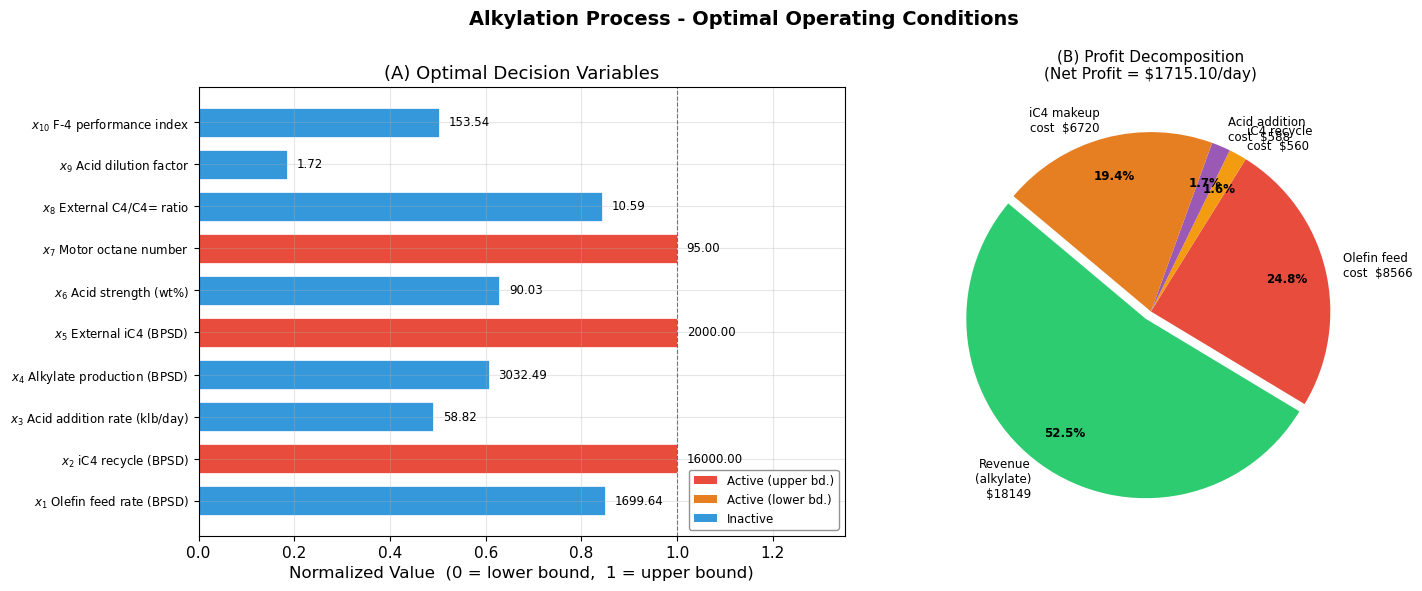


✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_04\figs\alkylation_optimization.png


In [32]:
# =====================================================================
# 視覺化：最優操作條件與獲利組成
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Alkylation Process - Optimal Operating Conditions', fontsize=14, fontweight='bold')

# English descriptions for Matplotlib labels (no Chinese characters)
var_desc_en = [
    'Olefin feed rate (BPSD)',
    'iC4 recycle (BPSD)',
    'Acid addition rate (klb/day)',
    'Alkylate production (BPSD)',
    'External iC4 (BPSD)',
    'Acid strength (wt%)',
    'Motor octane number',
    'External C4/C4= ratio',
    'Acid dilution factor',
    'F-4 performance index',
]

# -------------------------------------------------------
# 圖 (A): 最佳操作條件水平長條圖 (標準化值)
# -------------------------------------------------------
ax = axes[0]

# 計算各變數標準化值 (0 = 下限, 1 = 上限)
x_norm = (x_opt - x_lb) / (x_ub - x_lb)

# 識別活躍限制 (接近邊界的變數)
ACTIVE_THRESH = 0.02
colors = []
for xn in x_norm:
    if xn >= 1.0 - ACTIVE_THRESH:
        colors.append('#e74c3c')   # 達到上限 → 紅色
    elif xn <= ACTIVE_THRESH:
        colors.append('#e67e22')   # 達到下限 → 橘色
    else:
        colors.append('#3498db')   # 操作域內 → 藍色

y_pos = np.arange(10)
bars = ax.barh(y_pos, x_norm, color=colors, edgecolor='white', linewidth=0.5, height=0.7)

# 標示實際值
for i, (bar, xv) in enumerate(zip(bars, x_opt)):
    x_text = x_norm[i] + 0.02
    ax.text(x_text, i, f'{xv:.2f}', va='center', fontsize=8.5)

# Y-axis 標籤使用英文
ax.set_yticks(y_pos)
ax.set_yticklabels([f'$x_{{{i+1}}}$ {desc}' for i, desc in enumerate(var_desc_en)], fontsize=8.5)
ax.set_xlim(0, 1.35)
ax.set_xlabel('Normalized Value  (0 = lower bound,  1 = upper bound)')
ax.set_title('(A) Optimal Decision Variables')
ax.axvline(x=1.0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)

# 圖例放在右下，不遮蓋主要資訊
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Active (upper bd.)'),
    Patch(facecolor='#e67e22', label='Active (lower bd.)'),
    Patch(facecolor='#3498db', label='Inactive'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8.5,
          framealpha=0.85, edgecolor='gray')
ax.grid(axis='x', alpha=0.3)

# -------------------------------------------------------
# 圖 (B): 獲利組成分析圓餅圖
# -------------------------------------------------------
ax2 = axes[1]

x1, x2, x3, x4, x5, x6, x7, x8, x9, x10 = x_opt
revenue     = c1 * x4 * x7
cost_olefin = c2 * x1
cost_recycle= c3 * x2
cost_acid   = c4 * x3
cost_makeup = c5 * x5

labels = [
    f'Revenue\n(alkylate)\n${revenue:.0f}',
    f'Olefin feed\ncost  ${cost_olefin:.0f}',
    f'iC4 recycle\ncost  ${cost_recycle:.0f}',
    f'Acid addition\ncost  ${cost_acid:.0f}',
    f'iC4 makeup\ncost  ${cost_makeup:.0f}',
]
sizes   = [revenue, cost_olefin, cost_recycle, cost_acid, cost_makeup]
colors2 = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#e67e22']
explode = (0.05, 0, 0, 0, 0)

wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=colors2,
    autopct='%1.1f%%', startangle=140, explode=explode,
    textprops={'fontsize': 8.5},
    pctdistance=0.78,
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight('bold')

ax2.set_title(
    f'(B) Profit Decomposition\n(Net Profit = ${profit_opt:.2f}/day)',
    fontsize=11
)

plt.tight_layout()
fig_path = FIG_DIR / 'alkylation_optimization.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖檔已儲存: {fig_path}")


---
### 8. scipy.optimize 常用最適化函式

| SciPy 函式 | 問題類型 |
|---|---|
| `minimize_scalar(method='bounded')` | 單變數有界最適化 |
| `minimize(method='Nelder-Mead')` | 無限制多變數（無導數）|
| `minimize(method='BFGS')` | 無限制多變數（擬牛頓）|
| **`minimize(method='SLSQP')` + 多類限制** | **含等式/不等式/邊界之複雜 NLP** |
| `linprog()` | 線性規劃 |
| `milp()` | 混合整數線性規劃 |
| `differential_evolution()` | 全域最適化 |

In [34]:
# =====================================================================
# 最終結果彙整
# =====================================================================
print("=" * 60)
print("  Unit12 Example 04 — 重點結果彙整")
print("=" * 60)
print(f"\n  問題規模:")
print(f"    決策變數數量: 10 個")
print(f"    等式限制:     3 個（1 線性 + 2 非線性）")
print(f"    不等式限制:   8 個（4 非線性 + 4 線性）")
print(f"\n  最大化目標函數:")
print(f"    每日最大獲利 f* = ${profit_opt:.3f}")
print(f"\n  關鍵最佳操作條件:")
print(f"    烯烴進料量  x1* = {x_opt[0]:.2f} BPSD")
print(f"    異丁烷回流  x2* = {x_opt[1]:.2f} BPSD (達到上限 16000)")
print(f"    酸液添加率  x3* = {x_opt[2]:.2f} klb/day")
print(f"    產品產量    x4* = {x_opt[3]:.2f} BPSD")
print(f"    異丁烷外加  x5* = {x_opt[4]:.2f} BPSD (達到上限 2000)")
print(f"    辛烷值      x7* = {x_opt[6]:.4f}")
print(f"\n  注意事項:")
print(f"    1. 最大化問題轉換: min -f(x) → max f(x)")
print(f"    2. SciPy 不等式格式：fun(x)>=0（定義時需注意正負符號方向）")
print(f"    3. 等式限制殘差均在機器精度量級，確認解的可行性")
print("=" * 60)

  Unit12 Example 04 — 重點結果彙整

  問題規模:
    決策變數數量: 10 個
    等式限制:     3 個（1 線性 + 2 非線性）
    不等式限制:   8 個（4 非線性 + 4 線性）

  最大化目標函數:
    每日最大獲利 f* = $1715.105

  關鍵最佳操作條件:
    烯烴進料量  x1* = 1699.64 BPSD
    異丁烷回流  x2* = 16000.00 BPSD (達到上限 16000)
    酸液添加率  x3* = 58.82 klb/day
    產品產量    x4* = 3032.49 BPSD
    異丁烷外加  x5* = 2000.00 BPSD (達到上限 2000)
    辛烷值      x7* = 95.0000

  注意事項:
    1. 最大化問題轉換: min -f(x) → max f(x)
    2. SciPy 不等式格式：fun(x)>=0（定義時需注意正負符號方向）
    3. 等式限制殘差均在機器精度量級，確認解的可行性
